<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-05-26 10:33:23--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  36.9MB/s    in 6.3s    
2026-05-26 10:33:32 (32.0 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT * FROM main"

data = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.boxplot(data['CompTotal'].dropna())

plt.title("Box Plot of CompTotal")
plt.ylabel("CompTotal")

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect database
conn = sqlite3.connect('survey-results-public.sqlite')

# Load data
query = "SELECT * FROM main"
data = pd.read_sql_query(query, conn)

# Convert Age column to numeric
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')

# Create box plot
plt.figure(figsize=(8,5))
plt.boxplot(data['Age'].dropna())

plt.title("Box Plot of Age")
plt.ylabel("Age")

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


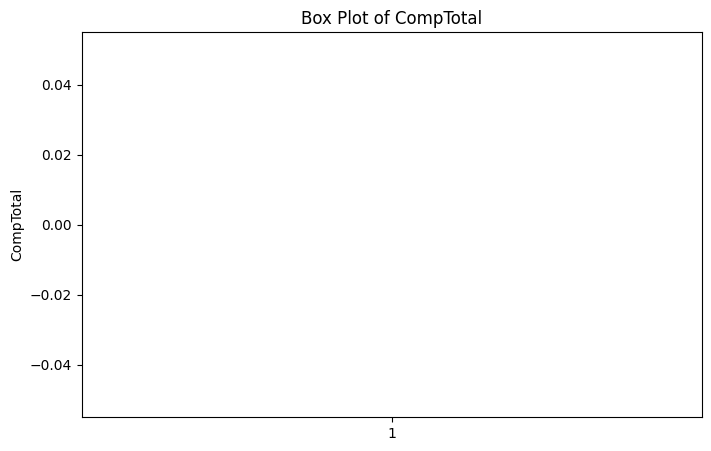

In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT Age, CompTotal FROM main"

data = pd.read_sql_query(query, conn)

data['Age'] = pd.to_numeric(data['Age'], errors='coerce')
data['CompTotal'] = pd.to_numeric(data['CompTotal'], errors='coerce')

# Remove missing values
data = data.dropna(subset=['Age', 'CompTotal'])

plt.figure(figsize=(8,5))

plt.boxplot(data['CompTotal'])

plt.title("Box Plot of CompTotal")
plt.ylabel("CompTotal")

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 1000x600 with 0 Axes>

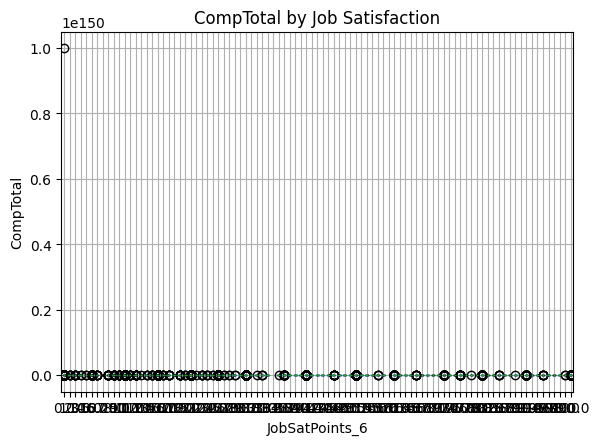

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT JobSatPoints_6, CompTotal FROM main"

data = pd.read_sql_query(query, conn)

data['JobSatPoints_6'] = pd.to_numeric(data['JobSatPoints_6'], errors='coerce')
data['CompTotal'] = pd.to_numeric(data['CompTotal'], errors='coerce')

plt.figure(figsize=(10,6))

data.boxplot(column='CompTotal', by='JobSatPoints_6')

plt.title("CompTotal by Job Satisfaction")
plt.suptitle("")
plt.ylabel("CompTotal")

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT DevType, ConvertedCompYearly FROM main"

data = pd.read_sql_query(query, conn)

data['ConvertedCompYearly'] = pd.to_numeric(data['ConvertedCompYearly'], errors='coerce')

top_dev = data['DevType'].value_counts().head(5).index

filtered = data[data['DevType'].isin(top_dev)]

plt.figure(figsize=(12,6))

filtered.boxplot(column='ConvertedCompYearly', by='DevType', rot=90)

plt.title("ConvertedCompYearly for Top 5 Developer Types")
plt.suptitle("")
plt.ylabel("Salary")

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT Country, CompTotal FROM main"

data = pd.read_sql_query(query, conn)

data['CompTotal'] = pd.to_numeric(data['CompTotal'], errors='coerce')

top_countries = data['Country'].value_counts().head(5).index

filtered = data[data['Country'].isin(top_countries)]

plt.figure(figsize=(12,6))

filtered.boxplot(column='CompTotal', by='Country', rot=45)

plt.title("CompTotal for Top 5 Countries")
plt.suptitle("")
plt.ylabel("CompTotal")

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1200x600 with 0 Axes>

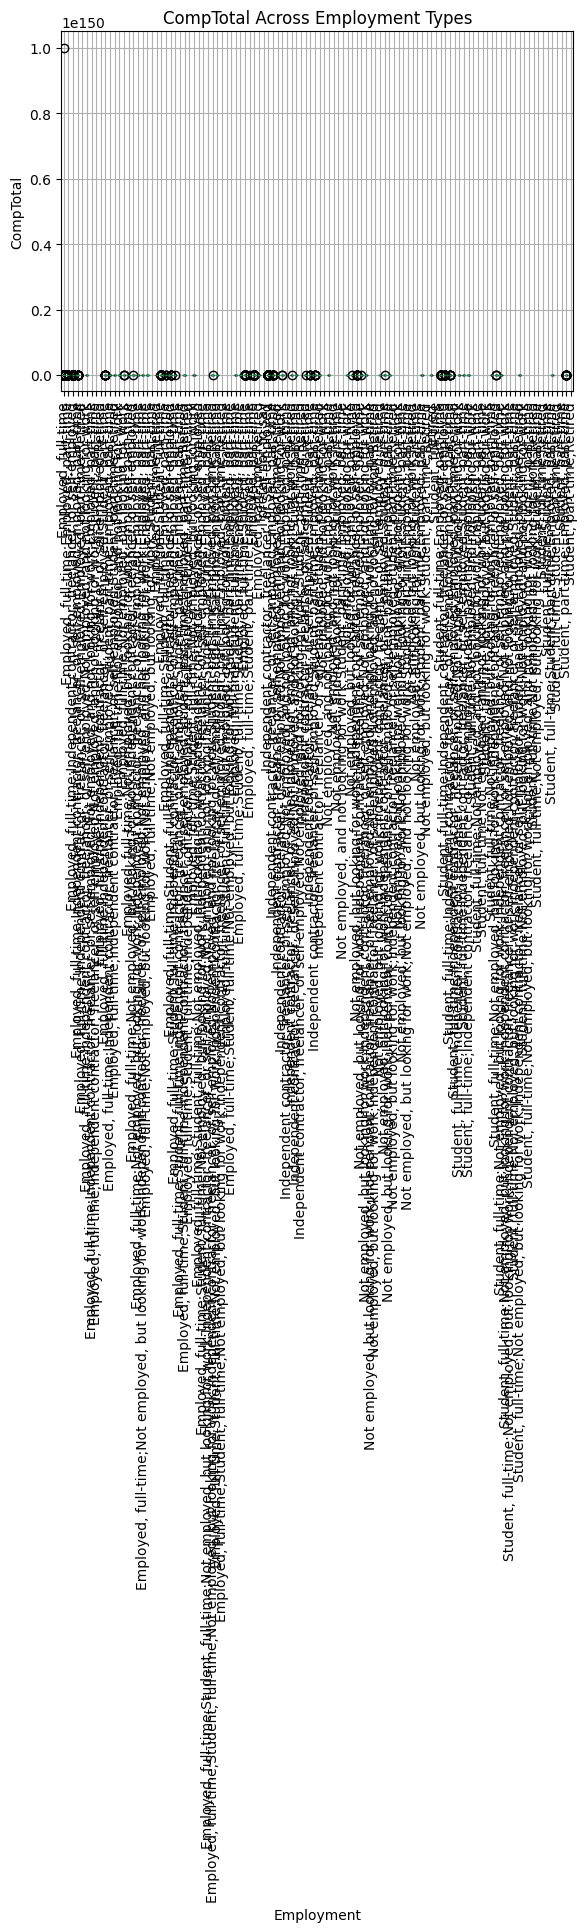

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT Employment, CompTotal FROM main"

data = pd.read_sql_query(query, conn)

data['CompTotal'] = pd.to_numeric(data['CompTotal'], errors='coerce')

plt.figure(figsize=(12,6))

data.boxplot(column='CompTotal', by='Employment', rot=90)

plt.title("CompTotal Across Employment Types")
plt.suptitle("")
plt.ylabel("CompTotal")

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


<Figure size 1000x600 with 0 Axes>

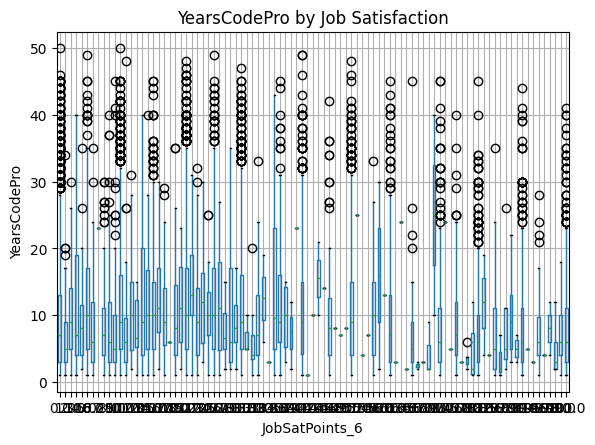

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('survey-results-public.sqlite')

query = "SELECT YearsCodePro, JobSatPoints_6 FROM main"

data = pd.read_sql_query(query, conn)

data['YearsCodePro'] = pd.to_numeric(data['YearsCodePro'], errors='coerce')
data['JobSatPoints_6'] = pd.to_numeric(data['JobSatPoints_6'], errors='coerce')

plt.figure(figsize=(10,6))

data.boxplot(column='YearsCodePro', by='JobSatPoints_6')

plt.title("YearsCodePro by Job Satisfaction")
plt.suptitle("")
plt.ylabel("YearsCodePro")

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [20]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
